- 这个脚本的目的是用来获取CAZy数据库中有功能注释酶的GT-A结构域的
- 选取三种方法结合的操作，与发表在Science上TED的文章处理方式一样，用来修正某一个具体工具可能存在的预测不准确问题
- 三个工具分别为：Merizo、Chainsaw、UniDoc
- 整体的流程分为：结构预测（pLDDT>60）->结构域划分->结构预测（pLDDT>70）
- 全部手动处理，按照elife文章做序列谱，只有序列谱中有保守基序的才是GT-A

# 确认家族的GT-A折叠类型

确认家族的GT-A的真实性，从DXD入手，但是在GT116上看到了DXK的序列，有点子离谱 (GT116是GalA的活性)

In [127]:
# # 提取家族序列
# from Bio import SeqIO
# from tqdm import tqdm

# family_name = 'GT116'

# i = 0

# with open(f"./data/cazy_annot_domain/{family_name}.fa", "w") as out_handle:
#     for record in tqdm(SeqIO.parse("./data/cazy_annot_domain/CAZyDB.07142024.fa", "fasta"), total=3613704):
#         if f"|{family_name}\n" in record.id+'\n' or f"|{family_name}|" in record.id or f"|{family_name}_" in record.id:
#             if 'X' in record.seq or 'Z' in record.seq or 'B' in record.seq or 'J' in record.seq or 'O' in record.seq or 'U' in record.seq:
#                 continue
#             if len(record.seq) > 700:
#                 continue
#             SeqIO.write(record, out_handle, "fasta")
#             i += 1

# print(f"Total sequences extracted: {i}")


In [ ]:
# # 绘制家族的序列谱
# # conda activate plottree
# print(f"cdhit -c 0.7 -i {family_name}.fa -o {family_name}_sub.fa -T 190 -M 30000")
# print(f"mafft --thread 190 --op 10 --ep 0.2 --auto {family_name}.fa > {family_name}.aln")


# 提取带有活性注释的GT-A序列和结构

- 提取方法分为以下步骤：
- （0）在进行所有处理前，清洗是NCBI来源的，并去除非标准氨基酸和重复。
- （1）首先是获取domain，这里就要分为两个部分处理，一个是能够从elife的数据中找到domain的，另一个是找不到domain的
- （2）针对找不到domain的，单独一个文件，在文件末尾放上10个有domain的示例，用序列比对来划分domain
- （3）如果是单一功能的，就使用所有的序列；如果是多功能的，就按70%序列相似性划分功能
- （4）domain长度在140~350
- （5）进行结构预测，并筛选pLDDT>80的结构并手动检查结构合理性

In [ ]:
# # 提取家族序列，并清洗
# from Bio import SeqIO
# from tqdm import tqdm

# family_name = 'GT6'

# i = 0

# with open(f"./data/cazy_annot_domain/{family_name}.fa", "w") as out_handle:
#     for record in tqdm(SeqIO.parse("./data/cazy_annot_domain/CAZyDB.07142024.fa", "fasta"), total=3613704):
#         if f"|{family_name}\n" in record.id+'\n' or f"|{family_name}|" in record.id or f"|{family_name}_" in record.id:
#             if 'X' in record.seq or 'Z' in record.seq or 'B' in record.seq or 'J' in record.seq or 'O' in record.seq or 'U' in record.seq:
#                 continue
#             if '.' not in record.id.split('|')[0]:
#                 continue
#             SeqIO.write(record, out_handle, "fasta")
#             i += 1

# print(f"Total sequences extracted: {i}")

# print(f"cdhit -c 1 -i {family_name}.fa -o {family_name}_sub.fa -T 190 -M 30000")

100%|██████████| 3613704/3613704 [00:37<00:00, 97494.63it/s] 

Total sequences extracted: 899
cdhit -c 1 -i GT6.fa -o GT6_sub.fa -T 190 -M 30000


## One Function Type

In [ ]:
# # 从elife文章中获取domain序列
# from Bio import SeqIO
# import pandas as pd
# from Bio.SeqRecord import SeqRecord
# from Bio.Seq import Seq

# domain_count = 0
# full_count = 0

# df_elife = pd.read_csv('./data/cazy_annot_domain/GTA_nr.tsv', sep='\t')
# elige_dic = {}
# for i in range(len(df_elife)):
#     elige_dic[df_elife['SequenceID'][i]] = (df_elife['DomainSequence'][i], df_elife['FullSequence'][i])

# # 划分domain和full序列
# domain_handle =  open(f"./data/cazy_annot_domain/{family_name}_domain.fa", "w")
# full_handle =  open(f"./data/cazy_annot_domain/{family_name}_full.fa", "w")
# for record in tqdm(SeqIO.parse(f"./data/cazy_annot_domain/{family_name}_sub.fa", "fasta")):
#     if record.id.split('|')[0] in elige_dic:
#         domain_seq, full_seq = elige_dic[record.id.split('|')[0]]
#         if record.seq != full_seq:
#             print(f"Error! {record.id} domain sequence not equal to full sequence!")
#             print(domain_seq)
#             print(full_seq)
#             continue
#         if 'X' in domain_seq or 'Z' in domain_seq or 'B' in domain_seq or 'J' in domain_seq or 'O' in domain_seq or 'U' in domain_seq:
#             print(f"Error! {record.id} domain sequence contains invalid characters!")
#             continue
#         record.seq = Seq(domain_seq)
#         record.id = record.id.replace('.','_')
#         SeqIO.write(record, domain_handle, "fasta")
#         domain_count += 1
#     else:
#         record.id = record.id.replace('.','_')
#         SeqIO.write(record, full_handle, "fasta")
#         full_count += 1

# domain_handle.close()

# # 写入10个示例domain序列
# i = 0
# for record in tqdm(SeqIO.parse(f"./data/cazy_annot_domain/{family_name}_domain.fa", "fasta")):
#     if i >= 10:
#         break
#     record.id = 'example_' + str(i)
#     SeqIO.write(record, full_handle, "fasta")
#     i += 1

# full_handle.close()

# print(f"mafft --thread 190 --op 10 --ep 0.2 --auto {family_name}_full.fa > {family_name}.aln")
# print(f"Domain sequences: {domain_count}, full sequences: {full_count}")
# print("请人工检查比对结果，去除非domain的序列，检查.aln文件")

115it [00:00, 31833.75it/s]
10it [00:00, 29289.83it/s]

mafft --thread 190 --op 10 --ep 0.2 --auto GT12_full.fa > GT12.aln
Domain sequences: 18, full sequences: 97
请人工检查比对结果，去除非domain的序列，检查.aln文件


In [ ]:
# # 强力整合人工选取domain和电脑的
# import os

# out_handle = open(f"./data/cazy_annot_domain/{family_name}_d.fa", "w")
# excel_handle = open(f"./data/cazy_annot_domain/{family_name}_conclusion.tsv", "w")
# excel_handle.write("ID\tFamily\tLength\n")

# small_count = 0
# middle_count = 0
# large_count = 0

# for record in tqdm(SeqIO.parse(f"./data/cazy_annot_domain/{family_name}_domain.fa", "fasta")):
#     if len(record.seq) > 140 and len(record.seq) < 350 and 'example_' not in record.id:
#         genbank_id = record.id.split('|')[0]
#         f_name = record.id.split(genbank_id+'|')[1]
#         excel_handle.write(f"{genbank_id}\t{f_name}\t{len(record.seq)}\n")
#         record.id = family_name + '_' + genbank_id
#         record.description = ""
#         SeqIO.write(record, out_handle, "fasta")
#         middle_count += 1
#     elif len(record.seq) < 140:
#         small_count += 1
#     elif len(record.seq) > 350:
#         large_count += 1

# for record in tqdm(SeqIO.parse(f"./data/cazy_annot_domain/{family_name}.aln", "fasta")):
#     record.seq = record.seq.replace('-','')
#     if len(record.seq) > 140 and len(record.seq) < 350 and 'example_' not in record.id:
#         record.id = record.id.split('/')[0]
#         genbank_id = record.id.split('|')[0]
#         f_name = record.id.split(genbank_id+'|')[1]
#         excel_handle.write(f"{genbank_id}\t{f_name}\t{len(record.seq)}\n")
#         record.id = family_name + '_' + genbank_id
#         record.description = ""
#         SeqIO.write(record, out_handle, "fasta")
#         middle_count += 1
#     elif len(record.seq) < 140:
#         small_count += 1
#     elif len(record.seq) > 350:
#         large_count += 1


# out_handle.close()
# excel_handle.close()

# os.makedirs(f"./data/cazy_annot_domain/{family_name}/", exist_ok=True)

# print(f"Small sequences: {small_count}, middle sequences: {middle_count}, large sequences: {large_count}")

# # export CUDA_VISIBLE_DEVICES=1

# print(f"cdhit -c 1 -i {family_name}_d.fa -o {family_name}_d_sub.fa -T 190 -M 30000")

# print(f"nohup python /home/admin123/esmfold/esm-main/scripts/fold.py \
#         -i {family_name}_d_sub.fa -o {family_name} -m /home/admin123/.cache/torch/hub/ \
#         --num-recycles 4 &")


18it [00:00, 31549.30it/s]
107it [00:00, 20154.96it/s]

Small sequences: 14, middle sequences: 101, large sequences: 0
cdhit -c 1 -i GT12_d.fa -o GT12_d_sub.fa -T 190 -M 30000
nohup python /home/admin123/esmfold/esm-main/scripts/fold.py         -i GT12_d_sub.fa -o GT12 -m /home/admin123/.cache/torch/hub/         --num-recycles 4 &


In [ ]:
# # 筛选结构，生成最终的文件
# import os

# os.makedirs(f"./data/cazy_annot_domain/{family_name}_r/", exist_ok=True)
# out_handle = open(f"./data/cazy_annot_domain/{family_name}_domain.fa", "w")
# excel_handle = open(f"./data/cazy_annot_domain/{family_name}_metadata.tsv", "w")
# excel_handle.write("ID\tFamily\tLength\tpLDDT\n")

# metadata_dict = {}
# df = pd.read_csv(f"./data/cazy_annot_domain/{family_name}_conclusion.tsv", sep='\t')
# for i in range(0,df.shape[0]):
#     metadata_dict[df['ID'][i]] = (df['Family'][i], df['Length'][i])
# sequence_dict = {}
# for record in tqdm(SeqIO.parse(f"./data/cazy_annot_domain/{family_name}_d_sub.fa", "fasta")):
#     record.description = ""
#     sequence_dict[record.id] = record

# with open('./data/cazy_annot_domain/nohup.out', 'r')as f:
#     lines = f.readlines()

# for i,line in enumerate(lines):
#     if i <= 3:
#         continue
#     pLDDT = line.split(', pLDDT ')[1].split(', pTM ')[0]
#     if float(pLDDT) < 80:
#         continue
#     f_name = line.split('Predicted structure for ')[1].split(' with length ')[0]
#     f_name = f_name.split(f"{family_name}_")[1]
#     os.system(f"cp ./data/cazy_annot_domain/{family_name}/{family_name}_{f_name}.pdb ./data/cazy_annot_domain/{family_name}_r/")
#     temp1, temp2 = metadata_dict[f_name]
#     excel_handle.write(f"{f_name}\t{temp1}\t{temp2}\t{pLDDT}\n")
#     SeqIO.write(sequence_dict[f"{family_name}_{f_name}"], out_handle, "fasta")

# excel_handle.close()
# out_handle.close()


93it [00:00, 92368.05it/s]


In [ ]:
# # ==========脚本内容：Protein_align.py==========
# import subprocess
# import os
# from tqdm import tqdm

# def get_all_files(directory):
#     all_files = []
#     # 遍历目录及其子目录
#     for root, dirs, files in os.walk(directory):
#         # 将每个文件的绝对路径添加到列表中
#         for file in files:
#             file_path = os.path.join(root, file)
#             all_files.append(file_path)
#     return all_files

# def delete_files_in_folder(folder_path):
#     # 获取文件夹下所有文件和子文件夹
#     for root, dirs, files in os.walk(folder_path):
#         # 删除所有文件
#         for file in files:
#             file_path = os.path.join(root, file)
#             os.remove(file_path)

# def delete_special_files_in_folder(folder_path, prefix, fila_n):
#     # 获取文件夹下所有文件和子文件夹
#     for root, dirs, files in os.walk(folder_path):
#         # 删除所有文件
#         for file in files:
#             if file.endswith(prefix) and file.startswith(fila_n):
#                 file_path = os.path.join(root, file)
#                 os.remove(file_path)

# directory = f"./data/cazy_annot_domain/{family_name}_r/"
# storage_direcroey = f"./data/cazy_annot_domain/{family_name}_aln/"
# os.makedirs(storage_direcroey, exist_ok=True)
# all_files = get_all_files(directory)
# delete_files_in_folder(storage_direcroey)
# # USalign结构比对==========
# exe_path = './data/exe/USalign'
# cluster_center_pdb = './data/elife_cluster_center.pdb'
# # USalign AAA.pdb cluster.pdb -o AAA
# for file in tqdm(all_files):
#     file = file.split('/')[-1]
#     temp1 = os.path.join(directory, file)
#     temp2 = os.path.join(storage_direcroey, file.rstrip('.pdb'))
#     subprocess.run([exe_path, temp1, cluster_center_pdb, '-o', temp2], stdout=subprocess.DEVNULL)
#     delete_special_files_in_folder(storage_direcroey, '.pml', file.rstrip('.pdb'))

# print("Pleace download the file of '_aln', '_domain.fa', '_metadata.tsv''")

100%|██████████| 32/32 [00:04<00:00,  7.19it/s]

Pleace download the file of '_aln', '_domain.fa', '_metadata.tsv''


## Many Function Type

In [ ]:
# # 从elife文章中获取domain序列 ========== 多功能特调 ==========
# from Bio import SeqIO
# import pandas as pd
# from Bio.SeqRecord import SeqRecord
# from Bio.Seq import Seq

# domain_count = 0
# full_count = 0

# df_elife = pd.read_csv('./data/cazy_annot_domain/GTA_nr.tsv', sep='\t')
# elige_dic = {}
# for i in range(len(df_elife)):
#     elige_dic[df_elife['SequenceID'][i]] = (df_elife['DomainSequence'][i], df_elife['FullSequence'][i])

# # 划分domain和full序列
# domain_handle =  open(f"./data/cazy_annot_domain/{family_name}_domain.fa", "w")
# full_handle =  open(f"./data/cazy_annot_domain/{family_name}_full.fa", "w")
# for record in tqdm(SeqIO.parse(f"./data/cazy_annot_domain/{family_name}_sub.fa", "fasta")):
#     if record.id.split('|')[0] in elige_dic:
#         domain_seq, full_seq = elige_dic[record.id.split('|')[0]]
#         if record.seq != full_seq:
#             print(f"Error! {record.id} domain sequence not equal to full sequence!")
#             print(domain_seq)
#             print(full_seq)
#             continue
#         if 'X' in domain_seq or 'Z' in domain_seq or 'B' in domain_seq or 'J' in domain_seq or 'O' in domain_seq or 'U' in domain_seq:
#             print(f"Error! {record.id} domain sequence contains invalid characters!")
#             continue
#         record.seq = Seq(domain_seq)
#         record.id = record.id.replace('.','_')
#         SeqIO.write(record, domain_handle, "fasta")
#         domain_count += 1
#     else:
#         record.id = record.id.replace('.','_')
#         SeqIO.write(record, full_handle, "fasta")
#         full_count += 1

# domain_handle.close()

# # ========== 多功能特调 ==========
# # 写入活性数据
# df = pd.read_excel('./data/cazy_annot_domain/表征数据.xlsx')
# df = df.loc[df['Family'] == family_name]
# df.reset_index(drop=True, inplace=True)
# Characterized_dic = {}
# for record in SeqIO.parse("./data/cazy_annot_domain/sequence.fasta", "fasta"):
#     Characterized_dic[record.id] = record.seq
# for i in range(0, df.shape[0]):
#     temp_id = df['GenBank'][i].replace('.','_')
#     temp_seq = Characterized_dic[temp_id]
#     record = SeqRecord(Seq(temp_seq), id='Characterized_' + temp_id, description="")
#     SeqIO.write(record, full_handle, "fasta")
# # ========== 多功能特调 ==========

# # 写入10个示例domain序列
# i = 0
# for record in tqdm(SeqIO.parse(f"./data/cazy_annot_domain/{family_name}_domain.fa", "fasta")):
#     if i >= 10:
#         break
#     record.id = 'example_' + str(i)
#     SeqIO.write(record, full_handle, "fasta")
#     i += 1

# full_handle.close()

# print(f"mafft --thread 190 --op 10 --ep 0.2 --auto {family_name}_full.fa > {family_name}.aln")
# print(f"Domain sequences: {domain_count}, full sequences: {full_count}")
# print("请人工检查比对结果，去除非domain的序列，检查.aln文件")

530it [00:00, 29381.19it/s]
10it [00:00, 30240.12it/s]

mafft --thread 190 --op 10 --ep 0.2 --auto GT6_full.fa > GT6.aln
Domain sequences: 285, full sequences: 245
请人工检查比对结果，去除非domain的序列，检查.aln文件


In [ ]:
# # # 从elife文章中获取domain序列 ========== 多功能特调 ========== GT2这种上万条的特别版，将序列以1w为单位进行拆分 ==========
# # from Bio import SeqIO
# # import pandas as pd
# # from Bio.SeqRecord import SeqRecord
# # from Bio.Seq import Seq
# # from tqdm import tqdm


# # sub_dic = {}
# # for record in SeqIO.parse(f"./data/cazy_annot_domain/{family_name}_sub.fa", "fasta"):
# #     sub_dic[record.id] = record.seq
# # chunk_size = 10000
# # items = list(sub_dic.items())
# # for i in range(0, len(items), chunk_size):
# #         chunk = items[i:i+chunk_size]
# #         file_num = i // chunk_size + 1
# #         # small_full_handle =  open(f"./data/cazy_annot_domain/{family_name}_{file_num}_sub.fa", "w") # 运行一次
# #         # for key, value in chunk:
# #         #     record = SeqRecord(Seq(value), id=key, description="")
# #         #     SeqIO.write(record, small_full_handle, "fasta")
# #         # small_full_handle.close()

# # print(f"File is split to {file_num} files, each containing {chunk_size} sequences.")
# # sub_num = 20 # =================================================================================================================== 关键

# # df_elife = pd.read_csv('./data/cazy_annot_domain/GTA_nr.tsv', sep='\t')
# # elige_dic = {}
# # for i in range(len(df_elife)):
# #     elige_dic[df_elife['SequenceID'][i]] = (df_elife['DomainSequence'][i], df_elife['FullSequence'][i])
# # domain_count = 0
# # full_count = 0
# # # 划分domain和full序列
# # domain_handle =  open(f"./data/cazy_annot_domain/{family_name}_domain.fa", "w")
# # full_handle =  open(f"./data/cazy_annot_domain/{family_name}_full.fa", "w")
# # for record in tqdm(SeqIO.parse(f"./data/cazy_annot_domain/{family_name}_{sub_num}_sub.fa", "fasta")):
# #     if record.id.split('|')[0] in elige_dic:
# #         domain_seq, full_seq = elige_dic[record.id.split('|')[0]]
# #         if record.seq != full_seq:
# #             # print(f"Error! {record.id} domain sequence not equal to full sequence!")
# #             # print(domain_seq)
# #             # print(full_seq)
# #             continue
# #         if 'X' in domain_seq or 'Z' in domain_seq or 'B' in domain_seq or 'J' in domain_seq or 'O' in domain_seq or 'U' in domain_seq:
# #             # print(f"Error! {record.id} domain sequence contains invalid characters!")
# #             continue
# #         record.seq = Seq(domain_seq)
# #         record.id = record.id.replace('.','_')
# #         SeqIO.write(record, domain_handle, "fasta")
# #         domain_count += 1
# #     else:
# #         record.id = record.id.replace('.','_')
# #         SeqIO.write(record, full_handle, "fasta")
# #         full_count += 1

# # domain_handle.close()

# # # ========== 多功能特调 ==========
# # # 写入活性数据
# # df = pd.read_excel('./data/cazy_annot_domain/表征数据.xlsx')
# # df = df.loc[df['Family'] == family_name]
# # df.reset_index(drop=True, inplace=True)
# # Characterized_dic = {}
# # for record in SeqIO.parse("./data/cazy_annot_domain/sequence.fasta", "fasta"):
# #     Characterized_dic[record.id] = record.seq
# # for i in range(0, df.shape[0]):
# #     temp_id = df['GenBank'][i].replace('.','_')
# #     temp_seq = Characterized_dic[temp_id]
# #     record = SeqRecord(Seq(temp_seq), id='Characterized_' + temp_id, description="")
# #     SeqIO.write(record, full_handle, "fasta")
# # # ========== 多功能特调 ==========

# # # 写入10个示例domain序列
# # i = 0
# # for record in tqdm(SeqIO.parse(f"./data/cazy_annot_domain/{family_name}_domain.fa", "fasta")):
# #     if i >= 50: # ================================================================================================= 关键，调整个数，减少aln中因为长度被筛选的序列
# #         break
# #     record.id = 'example_' + str(i)
# #     SeqIO.write(record, full_handle, "fasta")
# #     i += 1

# # full_handle.close()

# # print(f"mafft --thread 190 --op 10 --ep 0.2 --auto {family_name}_full.fa > {family_name}.aln")
# # print(f"Domain sequences: {domain_count}, full sequences: {full_count}")
# # print("请人工检查比对结果，去除非domain的序列，检查.aln文件")
# # print("在正式运行的时候关掉了error输出")

# # # 已经完成 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20
# # # 正在进行 
# # # mafft --thread 190 --op 10 --ep 0.2 --auto GT2_1_full.fa > GT2.aln

File is split to 20 files, each containing 10000 sequences.


9793it [00:00, 35507.34it/s]
50it [00:00, 18493.40it/s]

mafft --thread 190 --op 10 --ep 0.2 --auto GT2_full.fa > GT2.aln
Domain sequences: 705, full sequences: 9088
请人工检查比对结果，去除非domain的序列，检查.aln文件
在正式运行的时候关掉了error输出


In [ ]:
# # 强力整合人工选取domain和电脑的
# import os
# from tqdm import tqdm
# from Bio import SeqIO
# import pandas as pd
# from Bio.SeqRecord import SeqRecord
# from Bio.Seq import Seq

# out_handle = open(f"./data/cazy_annot_domain/{family_name}_d.fa", "w")
# Characterized_handle = open(f"./data/cazy_annot_domain/{family_name}_Characterized.fa", "w")
# excel_handle = open(f"./data/cazy_annot_domain/{family_name}_conclusion.tsv", "w")
# excel_handle.write("ID\tFamily\tLength\n")
# Characterized_excel_handle = open(f"./data/cazy_annot_domain/{family_name}_Characterized_conclusion.tsv", "w")
# Characterized_excel_handle.write("ID\tFamily\tLength\n")

# small_count = 0
# middle_count = 0
# large_count = 0

# for record in tqdm(SeqIO.parse(f"./data/cazy_annot_domain/{family_name}_domain.fa", "fasta")):
#     if len(record.seq) > 140 and len(record.seq) < 350 and 'example_' not in record.id:
#         genbank_id = record.id.split('|')[0]
#         f_name = record.id.split(genbank_id+'|')[1]
#         excel_handle.write(f"{genbank_id}\t{f_name}\t{len(record.seq)}\n")
#         record.id = family_name + '_' + genbank_id
#         record.description = ""
#         SeqIO.write(record, out_handle, "fasta")
#         middle_count += 1
#     elif len(record.seq) < 140:
#         small_count += 1
#     elif len(record.seq) > 350:
#         large_count += 1

# for record in tqdm(SeqIO.parse(f"./data/cazy_annot_domain/{family_name}.aln", "fasta")):
#     record.seq = record.seq.replace('-','')
#     # ========== 多功能特调 ==========
#     if len(record.seq) > 140 and len(record.seq) < 350 and 'Characterized_' in record.id:
#         record.id = record.id.split('/')[0]
#         genbank_id = record.id.split('Characterized_')[1]
#         f_name = family_name
#         Characterized_excel_handle.write(f"{genbank_id}\t{f_name}\t{len(record.seq)}\n")
#         record.id = family_name + '_' + genbank_id
#         record.description = ""
#         SeqIO.write(record, Characterized_handle, "fasta")
#         middle_count += 1
#     # ========== 多功能特调 ==========
#     elif len(record.seq) > 140 and len(record.seq) < 350 and 'example_' not in record.id:
#         record.id = record.id.split('/')[0]
#         genbank_id = record.id.split('|')[0]
#         f_name = record.id.split(genbank_id+'|')[1]
#         excel_handle.write(f"{genbank_id}\t{f_name}\t{len(record.seq)}\n")
#         record.id = family_name + '_' + genbank_id
#         record.description = ""
#         SeqIO.write(record, out_handle, "fasta")
#         middle_count += 1
#     elif len(record.seq) < 140:
#         small_count += 1
#     elif len(record.seq) > 350:
#         large_count += 1


# out_handle.close()
# excel_handle.close()
# Characterized_handle.close()
# Characterized_excel_handle.close()

# print(f"Small sequences: {small_count}, middle sequences: {middle_count}, large sequences: {large_count}")
# print(f"cdhit -c 1 -i {family_name}_d.fa -o {family_name}_d_sub.fa -T 190 -M 30000")
# print(f"cdhit -c 1 -i {family_name}_Characterized.fa -o {family_name}_Characterized_sub.fa -T 190 -M 30000")


285it [00:00, 27090.07it/s]
740it [00:00, 24401.02it/s]

Small sequences: 49, middle sequences: 962, large sequences: 4
cdhit -c 1 -i GT6_d.fa -o GT6_d_sub.fa -T 190 -M 30000
cdhit -c 1 -i GT6_Characterized.fa -o GT6_Characterized_sub.fa -T 190 -M 30000


In [ ]:
# # 多功能家族最关键的70%序列相似性部分 Step1
# # ========== 多功能特调 ==========
# wait_aln_handle = open(f"./data/cazy_annot_domain/{family_name}_wait_aln.fa", "w")
# for record in tqdm(SeqIO.parse(f"./data/cazy_annot_domain/{family_name}_d_sub.fa", "fasta")):
#     record.description = ""
#     SeqIO.write(record, wait_aln_handle, "fasta")
# for record in tqdm(SeqIO.parse(f"./data/cazy_annot_domain/{family_name}_Characterized_sub.fa", "fasta")):
#     record.description = ""
#     record.id = "Characterized_" + record.id
#     SeqIO.write(record, wait_aln_handle, "fasta")
# wait_aln_handle.close()

# print(f"mafft --thread 190 --op 10 --ep 0.2 --auto {family_name}_wait_aln.fa > {family_name}_wait_aln.aln")
# # ========== 多功能特调 ==========

446it [00:00, 34706.76it/s]
225it [00:00, 31021.94it/s]

mafft --thread 190 --op 10 --ep 0.2 --auto GT6_wait_aln.fa > GT6_wait_aln.aln


In [ ]:
# # 多功能家族最关键的70%序列相似性部分 Step1
# from itertools import combinations
# from multiprocessing import Pool, cpu_count

# def calculate_similarity(pair):
#     (key1, value1), (key2, value2) = pair
#     total_site = 0
#     similarity_site = 0
#     # 对齐两条序列并计算相似度
#     for site1, site2 in zip(value1, value2):
#         if site1 == '-' and site2 == '-':
#             continue
#         else:
#             total_site += 1
#             if site1 == site2:
#                 similarity_site += 1
#     similarity = similarity_site / total_site * 100
#     return f"{key1}\t{key2}\t{similarity:.2f}\n"
# # ========== 多功能特调 ==========
# out_handle = open(f"./data/cazy_annot_domain/{family_name}_70_similarity.tsv", "w", encoding='gbk')
# out_handle.write("GenBank\t活性\tNDP-Sugar活性\tProteinName\tCharacterized_GenBank\n")
# predict_handle = open(f"./data/cazy_annot_domain/{family_name}_wait_predict.fa", "w")

# Characterized_matadata = {}
# df = pd.read_excel('./data/cazy_annot_domain/表征数据.xlsx')
# df = df.loc[df['Family'] == family_name]
# df.reset_index(drop=True, inplace=True)
# for i in range(0, df.shape[0]):
#     temp_id = df['GenBank'][i].replace('.','_')
#     Characterized_matadata[temp_id] = (df['活性'][i], df['NDP-Sugar活性'][i], df['ProteinName'][i])

# cazy_dic = {}
# Characterized_dic = {}
# for record in SeqIO.parse(f"./data/cazy_annot_domain/{family_name}_wait_aln.aln", "fasta"):
#     record.description = ""
#     if 'Characterized_' in record.id:
#         Characterized_dic[record.id] = str(record.seq)
#     else:
#         cazy_dic[record.id] = str(record.seq)


# temp_handle = open(f"./data/cazy_annot_domain/{family_name}_temp.tsv", "w")
# temp_handle.write("Key1\tKey2\tSimilarity\n")
# pairs = []
# for key1, value1 in tqdm(cazy_dic.items()):
#     for key2, value2 in Characterized_dic.items():
#         pairs.append(((key1, value1), (key2, value2)))
# # 使用多进程并行计算相似度
# with Pool(processes=cpu_count()) as pool:
#     for result in tqdm(pool.imap(calculate_similarity, pairs), total=len(pairs)):
#         temp_handle.write(result)
    
# predict_count = 0
# df = pd.read_csv(f"./data/cazy_annot_domain/{family_name}_temp.tsv", sep='\t')
# for group_name, group_df in tqdm(df.groupby('Key1')):
#     group_df.sort_values(by='Similarity', ascending=False, inplace=True)
#     group_df.reset_index(drop=True, inplace=True)
#     if group_df['Similarity'][0] < 70:
#         continue
#     temp_Characterized_genbank = group_df['Key2'][0].split('Characterized_')[1].split(f"{family_name}_")[1]
#     matadata_1, matadata_2, matadata_3 = Characterized_matadata[temp_Characterized_genbank]
#     out_handle.write(f"{group_name}\t{matadata_1}\t{matadata_2}\t{matadata_3}\t{temp_Characterized_genbank}\n")
#     record = SeqRecord(Seq(cazy_dic[group_name].replace('-','')), id=group_name, description="")
#     SeqIO.write(record, predict_handle, "fasta")
#     predict_count += 1

# temp_handle.close()
# out_handle.close()
# predict_handle.close()
# # ========== 多功能特调 ==========

# # 结构预测
# os.makedirs(f"./data/cazy_annot_domain/{family_name}/", exist_ok=True)
# print(f"Predict structure for {predict_count}.")
# # export CUDA_VISIBLE_DEVICES=1
# print(f"nohup python /home/admin123/esmfold/esm-main/scripts/fold.py \
#         -i {family_name}_wait_predict.fa -o {family_name} -m /home/admin123/.cache/torch/hub/ \
#         --num-recycles 4 &")

100%|██████████| 446/446 [00:00<00:00, 2546.23it/s]

Predict structure for 321.
nohup python /home/admin123/esmfold/esm-main/scripts/fold.py         -i GT6_wait_predict.fa -o GT6 -m /home/admin123/.cache/torch/hub/         --num-recycles 4 &


In [ ]:
# # # GT2 这种活性特别多的结构的特调 =========================================================================================
# # print(f"cdhit -c 0.4 -n 2 -i {family_name}_wait_predict.fa -o {family_name}_wait_predict_sub.fa -T 190 -M 30000")
# # print(f"mafft --thread 190 --reorder --op 10 --ep 0.2 --auto {family_name}_wait_predict.fa > {family_name}_wait_predict.aln")
# # print("测试预测，方便调整参数")
# # os.makedirs(f"./data/cazy_annot_domain/{family_name}_test/", exist_ok=True)
# # print(f"python /home/admin123/esmfold/esm-main/scripts/fold.py \
# #         -i {family_name}_wait_predict_sub.fa -o {family_name}_test -m /home/admin123/.cache/torch/hub/ \
# #         --num-recycles 4")

cdhit -c 0.4 -n 2 -i GT2_wait_predict.fa -o GT2_wait_predict_sub.fa -T 190 -M 30000
mafft --thread 190 --reorder --op 10 --ep 0.2 --auto GT2_wait_predict.fa > GT2_wait_predict.aln
测试预测，方便调整参数
python /home/admin123/esmfold/esm-main/scripts/fold.py         -i GT2_wait_predict_sub.fa -o GT2_test -m /home/admin123/.cache/torch/hub/         --num-recycles 4


In [ ]:
# # # GT2 这种活性特别多的结构的特调 =========================================================================================
# # import subprocess
# # import os
# # from tqdm import tqdm

# # def get_all_files(directory):
# #     all_files = []
# #     # 遍历目录及其子目录
# #     for root, dirs, files in os.walk(directory):
# #         # 将每个文件的绝对路径添加到列表中
# #         for file in files:
# #             file_path = os.path.join(root, file)
# #             all_files.append(file_path)
# #     return all_files

# # def delete_files_in_folder(folder_path):
# #     # 获取文件夹下所有文件和子文件夹
# #     for root, dirs, files in os.walk(folder_path):
# #         # 删除所有文件
# #         for file in files:
# #             file_path = os.path.join(root, file)
# #             os.remove(file_path)

# # def delete_special_files_in_folder(folder_path, prefix, fila_n):
# #     # 获取文件夹下所有文件和子文件夹
# #     for root, dirs, files in os.walk(folder_path):
# #         # 删除所有文件
# #         for file in files:
# #             if file.endswith(prefix) and file.startswith(fila_n):
# #                 file_path = os.path.join(root, file)
# #                 os.remove(file_path)

# # directory = f"./data/cazy_annot_domain/{family_name}_test/"
# # storage_direcroey = f"./data/cazy_annot_domain/{family_name}_test_aln/"
# # os.makedirs(storage_direcroey, exist_ok=True)
# # all_files = get_all_files(directory)
# # delete_files_in_folder(storage_direcroey)
# # # USalign结构比对==========
# # exe_path = './data/exe/USalign'
# # cluster_center_pdb = './data/elife_cluster_center.pdb'
# # # USalign AAA.pdb cluster.pdb -o AAA
# # for file in tqdm(all_files):
# #     file = file.split('/')[-1]
# #     temp1 = os.path.join(directory, file)
# #     temp2 = os.path.join(storage_direcroey, file.rstrip('.pdb'))
# #     subprocess.run([exe_path, temp1, cluster_center_pdb, '-o', temp2], stdout=subprocess.DEVNULL)
# #     delete_special_files_in_folder(storage_direcroey, '.pml', file.rstrip('.pdb'))

# # print('Please download the file of "_test_aln" and "_wait_predict.aln"')

100%|██████████| 52/52 [00:09<00:00,  5.58it/s]

Please download the file of "_test_aln" and "_wait_predict.aln"


In [ ]:
# # # GT2 这种活性特别多的结构的特调 =========================================================================================
# # # 针对信息进行修正
# # predict_count = 0
# # conclusion_dic = {}
# # df = pd.read_csv(f"./data/cazy_annot_domain/{family_name}_conclusion.tsv", sep='\t')
# # for i in range(0,df.shape[0]):
# #     conclusion_dic[df['ID'][i]] = i

# # predict_handle = open(f"./data/cazy_annot_domain/{family_name}_wait_predict.fa", "w")
# # for record in tqdm(SeqIO.parse(f"./data/cazy_annot_domain/{family_name}_wait_predict.aln", "fasta")):
# #     record.id = record.id.split('/')[0]
# #     record.seq = record.seq.replace('-','')
# #     record.description = ""
# #     SeqIO.write(record, predict_handle, "fasta")
# #     refine_id = record.id.split(f"{family_name}_")[1]
# #     refine_length = len(record.seq)
# #     df['Length'][conclusion_dic[refine_id]] = refine_length
# #     predict_count += 1

# # df.to_csv(f"./data/cazy_annot_domain/{family_name}_conclusion.tsv", sep='\t', index=False)
# # predict_handle.close()

# # # 结构预测
# # os.makedirs(f"./data/cazy_annot_domain/{family_name}/", exist_ok=True)
# # print(f"Predict structure for {predict_count}.")
# # # export CUDA_VISIBLE_DEVICES=1
# # print(f"nohup python /home/admin123/esmfold/esm-main/scripts/fold.py \
# #         -i {family_name}_wait_predict.fa -o {family_name} -m /home/admin123/.cache/torch/hub/ \
# #         --num-recycles 4 &")

0it [00:00, ?it/s]/home/admin123/software/anaconda3/envs/starG/lib/python3.6/site-packages/ipykernel_launcher.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
461it [00:00, 9216.98it/s]

Predict structure for 461.
nohup python /home/admin123/esmfold/esm-main/scripts/fold.py         -i GT2_wait_predict.fa -o GT2 -m /home/admin123/.cache/torch/hub/         --num-recycles 4 &


In [ ]:
# # 筛选结构，生成最终的文件
# import os

# os.makedirs(f"./data/cazy_annot_domain/{family_name}_r/", exist_ok=True)
# out_handle = open(f"./data/cazy_annot_domain/{family_name}_domain.fa", "w")
# excel_handle = open(f"./data/cazy_annot_domain/{family_name}_metadata.tsv", "w", encoding='gbk')
# excel_handle.write("活性\tNDP-Sugar活性\tGenBank\tAnootFamily\tLength\tpLDDT\tActivities\t模板\n")

# metadata_dict = {}
# df = pd.read_csv(f"./data/cazy_annot_domain/{family_name}_conclusion.tsv", sep='\t')
# for i in range(0,df.shape[0]):
#     metadata_dict[df['ID'][i]] = (df['Family'][i], df['Length'][i])
# metadata_dict_2 = {}
# df = pd.read_csv(f"./data/cazy_annot_domain/{family_name}_70_similarity.tsv", sep='\t', encoding='gbk')
# for i in range(0,df.shape[0]):
#     metadata_dict_2[df['GenBank'][i]] = (df['活性'][i], df['NDP-Sugar活性'][i], df['ProteinName'][i], df['Characterized_GenBank'][i])
# sequence_dict = {}
# for record in tqdm(SeqIO.parse(f"./data/cazy_annot_domain/{family_name}_wait_predict.fa", "fasta")):
#     record.description = ""
#     sequence_dict[record.id] = record

# with open('./data/cazy_annot_domain/nohup.out', 'r')as f:
#     lines = f.readlines()

# for i,line in enumerate(lines):
#     if i <= 3:
#         continue
#     pLDDT = line.split(', pLDDT ')[1].split(', pTM ')[0]
#     if float(pLDDT) < 80:
#         continue
#     f_name = line.split('Predicted structure for ')[1].split(' with length ')[0]
#     f_name = f_name.split(f"{family_name}_")[1]
#     os.system(f"cp ./data/cazy_annot_domain/{family_name}/{family_name}_{f_name}.pdb ./data/cazy_annot_domain/{family_name}_r/")
#     temp1, temp2 = metadata_dict[f_name]
#     temp3, temp4, temp5, temp6 = metadata_dict_2[f"{family_name}_{f_name}"]
#     excel_handle.write(f"{temp3}\t{temp4}\t{f_name}\t{temp1}\t{temp2}\t{pLDDT}\t{temp5}\t{temp6}\n")
#     SeqIO.write(sequence_dict[f"{family_name}_{f_name}"], out_handle, "fasta")

# excel_handle.close()
# out_handle.close()


321it [00:00, 12204.57it/s]


In [ ]:
# # ==========脚本内容：Protein_align.py==========
# import subprocess
# import os
# from tqdm import tqdm

# def get_all_files(directory):
#     all_files = []
#     # 遍历目录及其子目录
#     for root, dirs, files in os.walk(directory):
#         # 将每个文件的绝对路径添加到列表中
#         for file in files:
#             file_path = os.path.join(root, file)
#             all_files.append(file_path)
#     return all_files

# def delete_files_in_folder(folder_path):
#     # 获取文件夹下所有文件和子文件夹
#     for root, dirs, files in os.walk(folder_path):
#         # 删除所有文件
#         for file in files:
#             file_path = os.path.join(root, file)
#             os.remove(file_path)

# def delete_special_files_in_folder(folder_path, prefix, fila_n):
#     # 获取文件夹下所有文件和子文件夹
#     for root, dirs, files in os.walk(folder_path):
#         # 删除所有文件
#         for file in files:
#             if file.endswith(prefix) and file.startswith(fila_n):
#                 file_path = os.path.join(root, file)
#                 os.remove(file_path)

# directory = f"./data/cazy_annot_domain/{family_name}_r/"
# storage_direcroey = f"./data/cazy_annot_domain/{family_name}_aln/"
# os.makedirs(storage_direcroey, exist_ok=True)
# all_files = get_all_files(directory)
# delete_files_in_folder(storage_direcroey)
# # USalign结构比对==========
# exe_path = './data/exe/USalign'
# cluster_center_pdb = './data/elife_cluster_center.pdb'
# # USalign AAA.pdb cluster.pdb -o AAA
# for file in tqdm(all_files):
#     file = file.split('/')[-1]
#     temp1 = os.path.join(directory, file)
#     temp2 = os.path.join(storage_direcroey, file.rstrip('.pdb'))
#     subprocess.run([exe_path, temp1, cluster_center_pdb, '-o', temp2], stdout=subprocess.DEVNULL)
#     delete_special_files_in_folder(storage_direcroey, '.pml', file.rstrip('.pdb'))

# print("Pleace download the file of '_aln', '_domain.fa', '_metadata.tsv''")

100%|██████████| 294/294 [00:45<00:00,  6.42it/s]

Pleace download the file of '_aln', '_domain.fa', '_metadata.tsv''


# =====以下废物=====

In [ ]:
# # ==========脚本内容：Protein_align.py==========
# import subprocess
# import os
# from tqdm import tqdm

# def get_all_files(directory):
#     all_files = []
#     # 遍历目录及其子目录
#     for root, dirs, files in os.walk(directory):
#         # 将每个文件的绝对路径添加到列表中
#         for file in files:
#             file_path = os.path.join(root, file)
#             all_files.append(file_path)
#     return all_files

# def delete_files_in_folder(folder_path):
#     # 获取文件夹下所有文件和子文件夹
#     for root, dirs, files in os.walk(folder_path):
#         # 删除所有文件
#         for file in files:
#             file_path = os.path.join(root, file)
#             os.remove(file_path)

# def delete_special_files_in_folder(folder_path, prefix, fila_n):
#     # 获取文件夹下所有文件和子文件夹
#     for root, dirs, files in os.walk(folder_path):
#         # 删除所有文件
#         for file in files:
#             if file.endswith(prefix) and file.startswith(fila_n):
#                 file_path = os.path.join(root, file)
#                 os.remove(file_path)

# directory = f"/home/admin123/temp/man_structure_1/ttt/"
# storage_direcroey = f"/home/admin123/temp/man_structure_1/ttt_aln/"
# os.makedirs(storage_direcroey, exist_ok=True)
# all_files = get_all_files(directory)
# delete_files_in_folder(storage_direcroey)
# # USalign结构比对==========
# exe_path = './data/exe/USalign'
# cluster_center_pdb = './data/elife_cluster_center.pdb'
# # USalign AAA.pdb cluster.pdb -o AAA
# for file in tqdm(all_files):
#     file = file.split('/')[-1]
#     temp1 = os.path.join(directory, file)
#     temp2 = os.path.join(storage_direcroey, file.rstrip('.pdb'))
#     subprocess.run([exe_path, temp1, cluster_center_pdb, '-o', temp2], stdout=subprocess.DEVNULL)
#     delete_special_files_in_folder(storage_direcroey, '.pml', file.rstrip('.pdb'))

# print("Pleace download the file of '_aln', '_domain.fa', '_metadata.tsv''")

100%|██████████| 230/230 [00:18<00:00, 12.27it/s]

Pleace download the file of '_aln', '_domain.fa', '_metadata.tsv''


# 矫正domain数据

In [ ]:
# import os
# from Bio import PDB
# from Bio.PDB.Polypeptide import is_aa, three_to_one
# from Bio.PDB.PDBExceptions import PDBConstructionWarning
# import warnings
# import pandas as pd
# from tqdm import tqdm
# from Bio import SeqIO
# from Bio.SeqRecord import SeqRecord
# from Bio.Seq import Seq

# def extract_sequences_from_pdb(pdb_file_path):
#     """提取PDB文件中各链的氨基酸序列"""
#     parser = PDB.PDBParser(QUIET=True)
#     sequences = {}
#     try:
#         structure = parser.get_structure('temp', pdb_file_path)
#         for model in structure:
#             for chain in model:
#                 chain_id = chain.id.strip()  # 清理链ID中的空格
#                 seq = []
#                 for residue in chain:
#                     res_name = residue.get_resname().strip().upper()  # 转换为大写并去除空格
#                     if is_aa(res_name, standard=True):
#                         try:
#                             seq.append(three_to_one(res_name))
#                         except KeyError:
#                             seq.append('X')  # 非标准氨基酸用X表示
#                 if seq:
#                     sequences[chain_id] = ''.join(seq)
#         return sequences
#     except Exception as e:
#         print(f"处理文件 {pdb_file_path} 时出错: {e}")
#         return {}

# domain_path = "./data/cazy_annot_domain/domain/"
# family_list = [int(x.split('_')[0].split('GT')[1]) for x in os.listdir(domain_path)]
# family_list = sorted(set(family_list))
# df = pd.read_excel('./data/cazy_annot_domain/纯纯GT-A_有NDP-Sugar活性注释.xlsx')
# df_result = pd.DataFrame(columns=df.columns)
# sequence_handle = open(f"./data/cazy_annot_domain/GTA_domain.fasta", "w")

# for family in family_list:

# # family = 111

#     family_path = os.path.join(domain_path, f"GT{family}_aln_check")
#     files = os.listdir(family_path)
#     df_sub = df.loc[df['Family'] == f"GT{family}"]
#     df_sub.reset_index(drop=True, inplace=True)
#     df_sub_dict = {x:df_sub.loc[df_sub['GenBank'] == x].values.tolist()[0] for x in df_sub['GenBank']}
#     df_temp = pd.DataFrame(columns=df.columns)
#     for file in tqdm(files, desc=f"Processing family GT{family}"):
#         pdb_path = os.path.join(family_path, file)
#         pdb_id = file.split('.pdb')[0]
#         chain_sequences = extract_sequences_from_pdb(pdb_path)
#         record = SeqRecord(Seq(chain_sequences['A']), id=pdb_id, description="")
#         SeqIO.write(record, sequence_handle, "fasta")
#         temp_loc = df_sub_dict[pdb_id.split(f"GT{family}_")[1]]
#         # 长度
#         temp_loc[6] = len(chain_sequences['A'])
#         # pLDDT
#         pLDDT_list = []
#         with open(os.path.join(family_path, file))as f:
#             lines = f.readlines()
#             for line in lines:
#                 if line.startswith("ATOM"):
#                     pLDDT_list.append(float(line[60:67].strip()))
#         temp_loc[7] = sum(pLDDT_list) / len(pLDDT_list)
#         # 修正
#         df_temp.loc[len(df_temp)] = temp_loc
#     df_result = pd.concat([df_result, df_temp], ignore_index=True)



# sequence_handle.close()
# df_result.to_excel(f"./data/cazy_annot_domain/GTA_domain_metadata.xlsx", index=False)

Processing family GT116: 100%|██████████| 3/3 [00:00<00:00, 36.78it/s]


# 结构数据分布情况

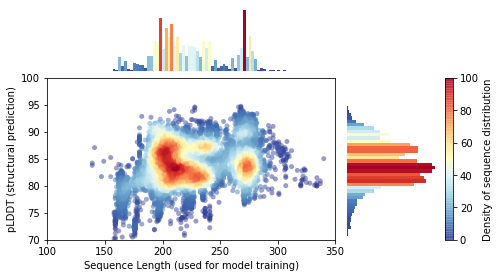

In [ ]:
# '''
# Plddt Quality Control
# '''
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import gaussian_kde
# import pandas as pd

# # 初始化存储序列长度和pLDDT值的列表
# sequence_lengths = []
# plddt_values = []

# # 从文件中读取序列长度和pLDDT值
# df = pd.read_excel('./data/cazy_annot_domain/GTA_domain_metadata.xlsx')

# # 提取数据
# for i in range(0, df.shape[0]):
#     sequence_lengths.append(df['Length'][i])
#     plddt_values.append(df['pLDDT'][i])

# # 分离pLDDT值小于70的数据，用于灰色标记
# x_gray = []
# y_gray = []
# for length, plddt in zip(sequence_lengths, plddt_values):
#     if plddt < 70:
#         x_gray.append(length)
#         y_gray.append(plddt)

# # 转换为NumPy数组，方便后续计算
# sequence_lengths = np.array(sequence_lengths)
# plddt_values = np.array(plddt_values)
# x_gray = np.array(x_gray)
# y_gray = np.array(y_gray)

# # 计算点的密度
# xy = np.vstack([sequence_lengths, plddt_values])
# density = gaussian_kde(xy)(xy)

# # 对密度进行归一化（0到100）
# min_density = np.min(density)
# max_density = np.max(density)
# density = (density - min_density) / (max_density - min_density) * 100

# # 定义颜色映射
# cmap = plt.cm.RdYlBu_r  # 使用反转的红黄蓝颜色映射
# norm = plt.Normalize(vmin=np.min(density), vmax=np.max(density))

# # 定义各个图形的布局参数
# border = 0.1  # 图像边距
# scatter_width = 0.5  # 散点图宽度
# hist_height = 0.2  # 直方图高度
# between = 0.02  # 图像间距

# # 布局位置
# scatter_pos = [border, border, scatter_width, scatter_width]
# hist_x_pos = [border, border + scatter_width + between, scatter_width, hist_height]
# hist_y_pos = [border + scatter_width + between, border, hist_height, scatter_width]

# # 创建图形
# plt.figure(figsize=(8, 4.5))
# scatter_ax = plt.axes(scatter_pos)  # 散点图
# hist_x_ax = plt.axes(hist_x_pos)   # X轴直方图
# hist_y_ax = plt.axes(hist_y_pos)   # Y轴直方图

# # 隐藏多余的坐标轴刻度
# hist_x_ax.set_xticks([])
# hist_y_ax.set_yticks([])
# hist_x_ax.axis('off')
# hist_y_ax.axis('off')

# # 绘制散点图，颜色表示密度
# scatter_ax.scatter(sequence_lengths, plddt_values, c=density, cmap=cmap, norm=norm, alpha=0.5, s=25, edgecolor='none')

# # 绘制颜色条表示密度
# cbar = plt.colorbar(scatter_ax.collections[0], ax=hist_y_ax)
# cbar.set_label('Density of sequence distribution')

# # 设置散点图的范围和标注
# scatter_ax.set_xlim(100, 350)
# scatter_ax.set_ylim(70, 100)
# # scatter_ax.axhline(y=70, color='red', linestyle='--', linewidth=2, label='pLDDT = 70')  # 添加红色虚线

# # # 在散点图中添加灰色的低质量点
# # scatter_ax.scatter(x_gray, y_gray, color='gray', alpha=0.5, s=25, edgecolor='none')

# # # 显示高质量点的比例
# # high_quality_ratio = (len(sequence_lengths) - len(x_gray)) / len(sequence_lengths)
# # scatter_ax.text(420, 94, f'{high_quality_ratio:.2%}', fontsize=14, color='red')

# # 添加直方图
# # X轴直方图
# hist_x, bins_x, patches_x = hist_x_ax.hist(sequence_lengths, bins=80, color='#F779BA')
# norm_x = plt.Normalize(vmin=min(hist_x), vmax=max(hist_x))
# colors_x = cmap(norm_x(hist_x))
# for patch, color in zip(patches_x, colors_x):
#     patch.set_facecolor(color)
# hist_x_ax.set_xlim(100, 350)

# # Y轴直方图
# hist_y, bins_y, patches_y = hist_y_ax.hist(plddt_values, bins=40, orientation='horizontal', color='#F779BA')
# norm_y = plt.Normalize(vmin=min(hist_y), vmax=max(hist_y))
# colors_y = cmap(norm_y(hist_y))
# for patch, color in zip(patches_y, colors_y):
#     patch.set_facecolor(color)
# hist_y_ax.set_ylim(70, 100)

# # 设置标签
# scatter_ax.set_xlabel('Sequence Length (used for model training)')
# scatter_ax.set_ylabel('pLDDT (structural prediction)')

# # 保存图像并显示
# output_path = './data/cazy_annot_domain/length_vs_pLDDT.png'
# plt.savefig(output_path, dpi=1200)
# output_path = './data/cazy_annot_domain/length_vs_pLDDT.svg'
# plt.savefig(output_path, format='svg', dpi=1200)
# plt.show()

# 统计家族活性数据

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import math

# activate_index = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
#                   'UDP-Gal': 3, 'UDP-GalNAc': 4, 'UDP-GalA': 5,
#                   'UDP-Xyl': 6, 'GDP-Man': 7, 'GDP-Fuc': 8,
#                   'dTDP-Rha': 9, 'Other': 10}

# metadata_handle = open(f"./data/cazy_annot_domain/GTA_domain_metadata.tsv", "w")
# metadata_handle.write("Family\t" + "\t".join(activate_index.keys()) + "\n")
# df = pd.read_excel('./data/cazy_annot_domain/GTA_domain_metadata.xlsx')
# data = []
# family_list = df['Family'].unique()
# for family in family_list:
#     group_df = df.loc[df['Family'] == family]
#     group_df.reset_index(drop=True, inplace=True)
#     temp_data = np.zeros((11, ), dtype=int)
#     for i in range(0, group_df.shape[0]):
#         if '[' in group_df['NDP-Sugar活性'][i]:
#             temp_data[activate_index['Other']] += 1
#         else:
#             temp_data[activate_index[group_df['NDP-Sugar活性'][i]]] += 1
#     metadata_handle.write(f"{family}\t" + "\t".join([str(x) for x in temp_data]) + "\n")
#     temp_data = [math.log10(x+1) for x in temp_data]
#     data.append(temp_data)
# data = np.array(data)
# data = data.T

# metadata_handle.close()

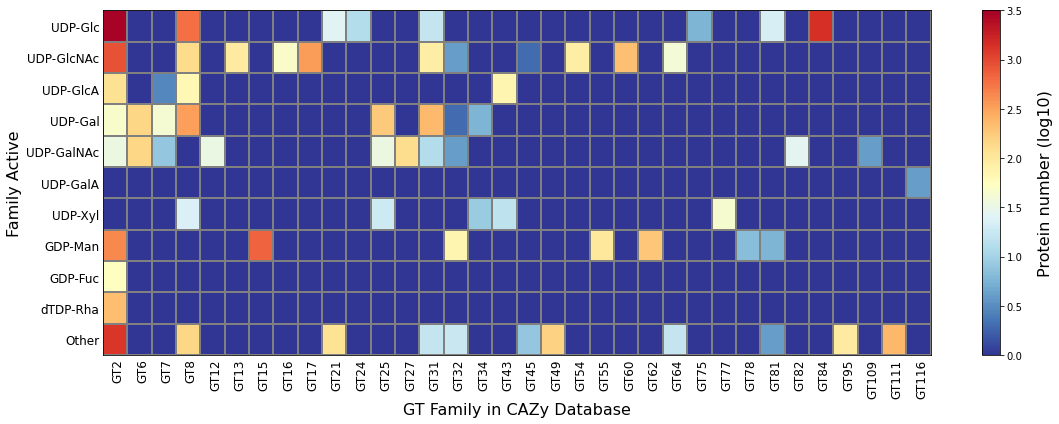

In [ ]:
# # # 创建标签
# row_labels = [x for x in activate_index.keys()]
# col_labels = [x for x in family_list]

# # 创建画布
# fig, ax = plt.subplots(figsize=(16, 6))

# # 绘制热图
# cmap = plt.cm.RdYlBu_r
# heatmap = ax.imshow(data,
#                     cmap=cmap,
#                     aspect='auto',
#                     interpolation='nearest',
#                     vmin=0, vmax=3.5)  # 固定颜色范围

# # 添加颜色条
# cbar = fig.colorbar(heatmap, ax=ax)
# cbar.set_label('Protein number (log10)', labelpad=15, size=16)

# # 设置坐标轴
# ax.set_xticks(np.arange(data.shape[1])+0.4)
# ax.set_yticks(np.arange(data.shape[0]))
# ax.set_xticklabels(col_labels, rotation=90, ha='right', size=12)
# ax.set_yticklabels(row_labels, size=12)
# ax.tick_params(axis='both', 
#                which='both', 
#                length=0)  # 刻度线长度设为0

# # 添加网格线
# ax.set_xticks(np.arange(data.shape[1]+1)-0.5, minor=True)
# ax.set_yticks(np.arange(data.shape[0]+1)-0.5, minor=True)
# ax.grid(which="minor", color="gray", linestyle='-', linewidth=2)
# ax.tick_params(which="minor", length=0)

# # # 设置标签
# ax.set_xlabel('GT Family in CAZy Database', size=16)
# ax.set_ylabel('Family Active', size=16)

# # 优化布局
# plt.tight_layout()

# # 保存图像并显示
# output_path = './data/cazy_annot_domain/structure_active_distribution.png'
# plt.savefig(output_path, dpi=1200)
# output_path = './data/cazy_annot_domain/structure_active_distribution.svg'
# plt.savefig(output_path, format='svg', dpi=1200)
# plt.show()


# 重新获取代表结构，然后进行USalign

In [ ]:
# foldseek easy-cluster all/ res tmp -c 0.6 --alignment-type 1

In [ ]:
# # ==========脚本内容：Protein_align.py==========
# import subprocess
# import os
# from tqdm import tqdm

# def get_all_files(directory):
#     all_files = []
#     # 遍历目录及其子目录
#     for root, dirs, files in os.walk(directory):
#         # 将每个文件的绝对路径添加到列表中
#         for file in files:
#             file_path = os.path.join(root, file)
#             all_files.append(file_path)
#     return all_files

# def delete_files_in_folder(folder_path):
#     # 获取文件夹下所有文件和子文件夹
#     for root, dirs, files in os.walk(folder_path):
#         # 删除所有文件
#         for file in files:
#             file_path = os.path.join(root, file)
#             os.remove(file_path)

# def delete_special_files_in_folder(folder_path, prefix, fila_n):
#     # 获取文件夹下所有文件和子文件夹
#     for root, dirs, files in os.walk(folder_path):
#         # 删除所有文件
#         for file in files:
#             if file.endswith(prefix) and file.startswith(fila_n):
#                 file_path = os.path.join(root, file)
#                 os.remove(file_path)

# directory_path = './data/cazy_annot_domain/domain/original/'
# storage_path = './data/cazy_annot_domain/domain/align/'
# folders = os.listdir(directory_path)

# for folder in folders:
#     directory = os.path.join(directory_path, folder)
#     storage_direcroey = os.path.join(storage_path, folder)
#     os.makedirs(storage_direcroey, exist_ok=True)
#     all_files = get_all_files(directory)
#     delete_files_in_folder(storage_direcroey)
#     # USalign结构比对==========
#     exe_path = './data/exe/USalign'
#     cluster_center_pdb = './data/cazy_cluster_center.pdb'
#     # USalign AAA.pdb cluster.pdb -o AAA
#     for file in tqdm(all_files, desc=f"Processing {folder}"):
#         file = file.split('/')[-1]
#         temp1 = os.path.join(directory, file)
#         temp2 = os.path.join(storage_direcroey, file.rstrip('.pdb'))
#         subprocess.run([exe_path, temp1, cluster_center_pdb, '-o', temp2], stdout=subprocess.DEVNULL)
#         delete_special_files_in_folder(storage_direcroey, '.pml', file.rstrip('.pdb'))


Processing GT16_aln_check: 100%|██████████| 48/48 [00:04<00:00, 10.81it/s]
